# Questão 8 - Método de Runge-Kutta de Quarta Ordem

Repita o Exercício 2 usando o método de Runge-Kutta de quarta ordem.

## Letra a)
$$y' = e^{t-y}, \quad 0 \leq t \leq 1, \quad y(0) = 1, \quad \text{com } h = 0,5$$

## Letra b)
$$y' = \frac{1+t}{1+y}, \quad 1 \leq t \leq 2, \quad y(1) = 2, \quad \text{com } h = 0,5$$

## Letra c)
$$y' = -y + ty^{1/2}, \quad 2 \leq t \leq 3, \quad y(2) = 2, \quad \text{com } h = 0,25$$

## Letra d)
$$y' = t^{-2}(\sin(2t) - 2ty), \quad 1 \leq t \leq 2, \quad y(1) = 2, \quad \text{com } h = 0,25$$

QUESTÃO 10 - RUNGE-KUTTA PARA SISTEMAS

 LETRA A 
t		u1 (aprox)	u1 (real)		u2 (aprox)	u2 (real)
0.00		-1.00000000	-1.00000000	0.00000000	0.00000000
0.10		-0.90070000	-0.90070138	0.12070000	0.12070138
0.20		-0.80590898	-0.80591235	0.28590898	0.28591235
0.30		-0.72105323	-0.72105940	0.50105323	0.50105940
0.40		-0.65276041	-0.65277046	0.77276041	0.77277046
0.50		-0.60912557	-0.60914091	1.10912557	1.10914091
0.60		-0.60003597	-0.60005846	1.52003597	1.52005846
0.70		-0.63756793	-0.63759998	2.01756793	2.01759998
0.80		-0.73647147	-0.73651621	2.61647147	2.61651621
0.90		-0.91476226	-0.91482373	3.33476226	3.33482373
1.00		-1.19444462	-1.19452805	4.19444462	4.19452805

 LETRA B
t		u1 (aprox)	u1 (real)		u2 (aprox)	u2 (real)
0.00		-3.00000000	-3.00000000	5.00000000	5.00000000
0.20		-3.62420001	-3.62420827	5.28560000	5.28561103
0.40		-4.31545390	-4.31547409	5.76727184	5.76729879
0.60		-5.10631940	-5.10635640	6.48842583	6.48847520
0.80		-6.03656252	-6.03662279	7.50208330	7.50216371
1.00		-7.1547534

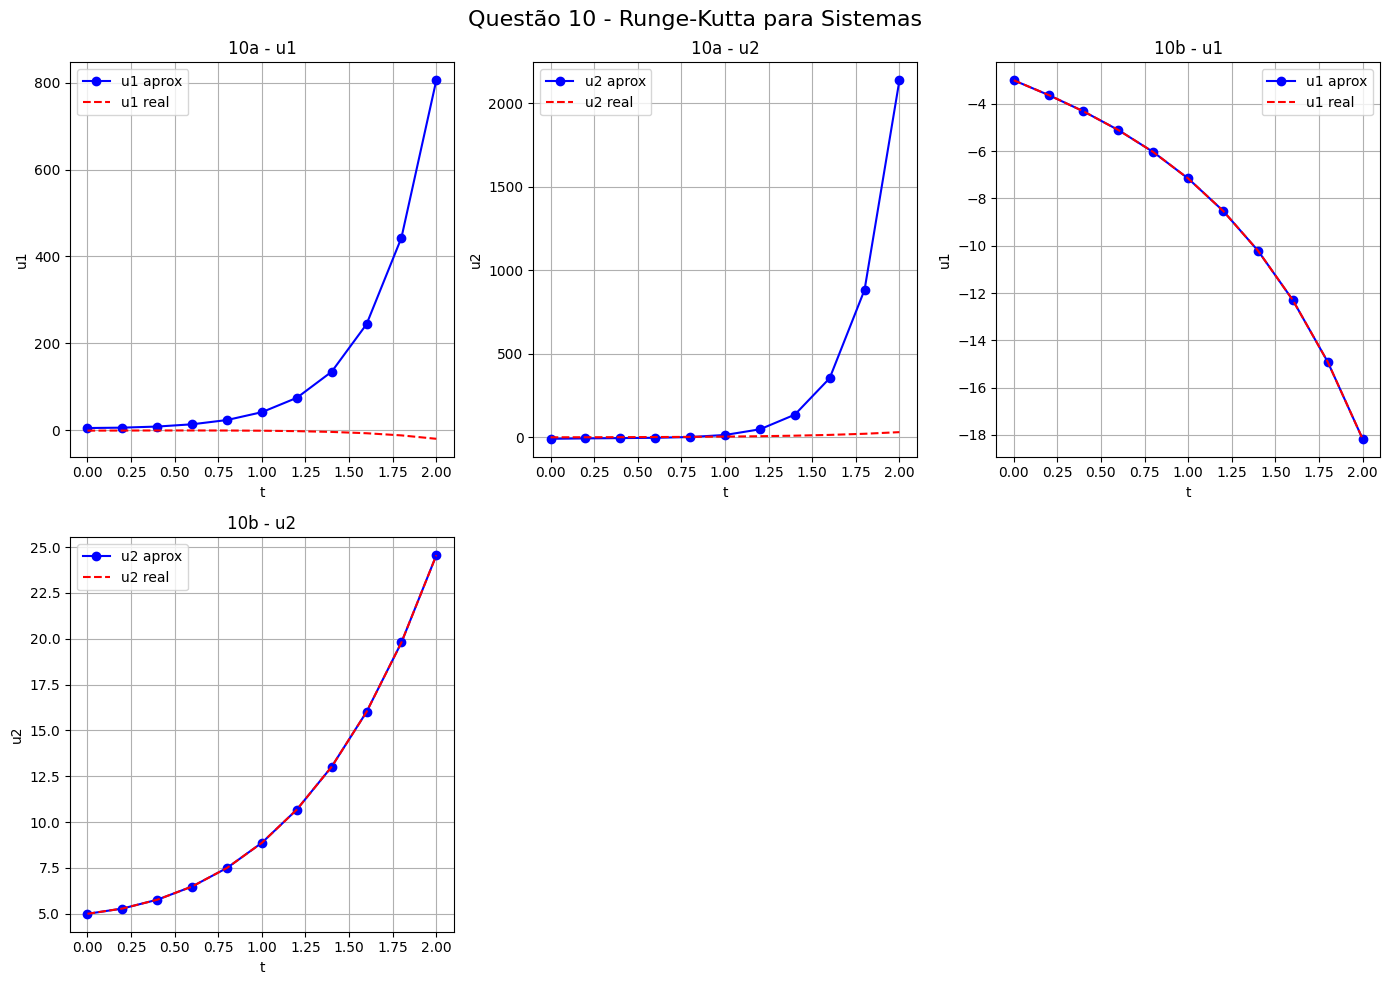

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rk4_system_2d(f1, f2, t0, u1_0, u2_0, h, t_end):
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        
        k1_1 = f1(t_curr, u1_curr, u2_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr)
        
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2)
        
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2)
        
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2)
        
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        t[i+1] = t_curr + h
    
    return t, u1, u2

def rk4_system_3d(f1, f2, f3, t0, u1_0, u2_0, u3_0, h, t_end):
    n = int((t_end - t0) / h)
    t = np.zeros(n+1)
    u1 = np.zeros(n+1)
    u2 = np.zeros(n+1)
    u3 = np.zeros(n+1)
    t[0] = t0
    u1[0] = u1_0
    u2[0] = u2_0
    u3[0] = u3_0
    
    for i in range(n):
        t_curr = t[i]
        u1_curr = u1[i]
        u2_curr = u2[i]
        u3_curr = u3[i]
        
        k1_1 = f1(t_curr, u1_curr, u2_curr, u3_curr)
        k1_2 = f2(t_curr, u1_curr, u2_curr, u3_curr)
        k1_3 = f3(t_curr, u1_curr, u2_curr, u3_curr)
        
        k2_1 = f1(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        k2_2 = f2(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        k2_3 = f3(t_curr + h/2, u1_curr + (h/2)*k1_1, u2_curr + (h/2)*k1_2, u3_curr + (h/2)*k1_3)
        
        k3_1 = f1(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        k3_2 = f2(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        k3_3 = f3(t_curr + h/2, u1_curr + (h/2)*k2_1, u2_curr + (h/2)*k2_2, u3_curr + (h/2)*k2_3)
        
        k4_1 = f1(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        k4_2 = f2(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        k4_3 = f3(t_curr + h, u1_curr + h*k3_1, u2_curr + h*k3_2, u3_curr + h*k3_3)
        
        u1[i+1] = u1_curr + (h/6)*(k1_1 + 2*k2_1 + 2*k3_1 + k4_1)
        u2[i+1] = u2_curr + (h/6)*(k1_2 + 2*k2_2 + 2*k3_2 + k4_2)
        u3[i+1] = u3_curr + (h/6)*(k1_3 + 2*k2_3 + 2*k3_3 + k4_3)
        t[i+1] = t_curr + h
    
    return t, u1, u2, u3

#Letra A
def f10a1(t, u1, u2):
    return u1 - u2 + 2

def f10a2(t, u1, u2):
    return -u1 + u2 + 4*t

def sol10a1(t):
    return -0.5*np.exp(2*t) + t**2 + 2*t - 0.5

def sol10a2(t):
    return 0.5*np.exp(2*t) + t**2 - 0.5

t0, u1_0, u2_0, h, t_end = 0, -1, 0, 0.1, 1
t, u1, u2 = rk4_system_2d(f10a1, f10a2, t0, u1_0, u2_0, h, t_end)


print("QUESTÃO 10 - RUNGE-KUTTA PARA SISTEMAS")

print("\n LETRA A ")
print("t\t\tu1 (aprox)\tu1 (real)\t\tu2 (aprox)\tu2 (real)")

for i in range(len(t)):
    print(f"{t[i]:.2f}\t\t{u1[i]:.8f}\t{sol10a1(t[i]):.8f}\t{u2[i]:.8f}\t{sol10a2(t[i]):.8f}")

#Letra B
def f10b1(t, u1, u2):
    return (1/9)*u1 - (2/3)*u2 - (1/9)*t**2 + (2/3)

def f10b2(t, u1, u2):
    return u2 + 3*t - 4

def sol10b1(t):
    return -3*np.exp(t) + t**2

def sol10b2(t):
    return 4*np.exp(t) - 3*t + 1

t0, u1_0, u2_0, h, t_end = 0, -3, 5, 0.2, 2
t, u1, u2 = rk4_system_2d(f10b1, f10b2, t0, u1_0, u2_0, h, t_end)

print("\n LETRA B")
print("t\t\tu1 (aprox)\tu1 (real)\t\tu2 (aprox)\tu2 (real)")

for i in range(len(t)):
    print(f"{t[i]:.2f}\t\t{u1[i]:.8f}\t{sol10b1(t[i]):.8f}\t{u2[i]:.8f}\t{sol10b2(t[i]):.8f}")

#Letra C
def f10c1(t, u1, u2, u3):
    return u1 + 2*u2 - 2*u3 + np.exp(-t)

def f10c2(t, u1, u2, u3):
    return u2 + u3 - 2*np.exp(-t)

def f10c3(t, u1, u2, u3):
    return u1 + 2*u2 + np.exp(-t)

def sol10c1(t):
    return -3*np.exp(-t) - 3*np.sin(t) + 6*np.cos(t)

def sol10c2(t):
    return 1.5*np.exp(-t) + 0.3*np.sin(t) - 2.1*np.cos(t) - 0.4*np.exp(2*t)

def sol10c3(t):
    return -np.exp(-t) + 2.4*np.cos(t) + 1.8*np.sin(t) - 0.4*np.exp(2*t)

t0, u1_0, u2_0, u3_0, h, t_end = 0, 3, -1, 1, 0.1, 1
t, u1, u2, u3 = rk4_system_3d(f10c1, f10c2, f10c3, t0, u1_0, u2_0, u3_0, h, t_end)

print("\nLETRA C ")
print("t\t\tu1 (aprox)\tu1 (real)\t\tu2 (aprox)\tu2 (real)\t\tu3 (aprox)\tu3 (real)")

for i in range(len(t)):
    print(f"{t[i]:.2f}\t\t{u1[i]:.8f}\t{sol10c1(t[i]):.8f}\t{u2[i]:.8f}\t{sol10c2(t[i]):.8f}\t{u3[i]:.8f}\t{sol10c3(t[i]):.8f}")

# Letra D
def f10d1(t, u1, u2, u3):
    return 3*u1 + 2*u2 - u3 - 1 - 3*t - 2*np.sin(t)

def f10d2(t, u1, u2, u3):
    return u1 - 2*u2 + 3*u3 + 6 - t + 2*np.sin(t) + np.cos(t)

def f10d3(t, u1, u2, u3):
    return 2*u1 + 4*u3 + 8 - 2*t

def sol10d1(t):
    return 2*np.exp(3*t) + 3*np.exp(-2*t) + t

def sol10d2(t):
    return -8*np.exp(-2*t) + np.exp(4*t) - 2*np.exp(3*t) + np.sin(t)

def sol10d3(t):
    return 2*np.exp(4*t) - 4*np.exp(3*t) - np.exp(-2*t) - 2

t0, u1_0, u2_0, u3_0, h, t_end = 0, 5, -9, -5, 0.2, 2
t, u1, u2, u3 = rk4_system_3d(f10d1, f10d2, f10d3, t0, u1_0, u2_0, u3_0, h, t_end)

print("\nLETRA D ")
print("t\t\tu1 (aprox)\tu1 (real)\t\tu2 (aprox)\tu2 (real)\t\tu3 (aprox)\tu3 (real)")

for i in range(len(t)):
    print(f"{t[i]:.2f}\t\t{u1[i]:.8f}\t{sol10d1(t[i]):.8f}\t{u2[i]:.8f}\t{sol10d2(t[i]):.8f}\t{u3[i]:.8f}\t{sol10d3(t[i]):.8f}")

# Gráficos
plt.figure(figsize=(14, 10))

# Letra A
plt.subplot(2, 3, 1)
plt.plot(t, u1, 'bo-', label='u1 aprox')
plt.plot(t, sol10a1(t), 'r--', label='u1 real')
plt.xlabel('t')
plt.ylabel('u1')
plt.title('10a - u1')
plt.grid(True)
plt.legend()

plt.subplot(2, 3, 2)
plt.plot(t, u2, 'bo-', label='u2 aprox')
plt.plot(t, sol10a2(t), 'r--', label='u2 real')
plt.xlabel('t')
plt.ylabel('u2')
plt.title('10a - u2')
plt.grid(True)
plt.legend()

# Letra B
t0, u1_0, u2_0, h, t_end = 0, -3, 5, 0.2, 2
t_b, u1_b, u2_b = rk4_system_2d(f10b1, f10b2, t0, u1_0, u2_0, h, t_end)

plt.subplot(2, 3, 3)
plt.plot(t_b, u1_b, 'bo-', label='u1 aprox')
plt.plot(t_b, sol10b1(t_b), 'r--', label='u1 real')
plt.xlabel('t')
plt.ylabel('u1')
plt.title('10b - u1')
plt.grid(True)
plt.legend()

plt.subplot(2, 3, 4)
plt.plot(t_b, u2_b, 'bo-', label='u2 aprox')
plt.plot(t_b, sol10b2(t_b), 'r--', label='u2 real')
plt.xlabel('t')
plt.ylabel('u2')
plt.title('10b - u2')
plt.grid(True)
plt.legend()

plt.suptitle('Questão 10 - Runge-Kutta para Sistemas', fontsize=16)
plt.tight_layout()
plt.show()